# MLP com PyTorch - Guia Completo

Este notebook cobre os três principais tipos de problemas usando **Multilayer Perceptron (MLP)** com PyTorch:

1. **Regressão** — prever valores contínuos (Boston Housing)
2. **Classificação Binária** — prever duas classes (Diabetes)
3. **Classificação Multiclasse** — prever múltiplas classes (Wine)

Todos os exemplos utilizam:
- `Dataset` e `DataLoader` para carregar dados em lotes (batches)
- `StandardScaler` para normalização dos dados
- Separação entre **treino** e **teste** para evitar overfitting
- **Persistência** de modelo (salvar e carregar pesos)
- **Persistência** do scaler (salvar e carregar com joblib)
- Métricas de avaliação e gráficos de convergência

---
## Instalação e Imports Gerais

In [1]:
# Instalar dependências (descomente se necessário)
!pip install torch torchvision scikit-learn joblib matplotlib pandas

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ----- ---------------------------------- 15.7/114.6 MB 78.6 MB/s eta 0:00:02
   ------------- -------------------------- 39.3/114.6 MB 94.6 MB/s eta 0:00:01
   -------------------- ------------------- 57.4/114.6 MB 92.8 MB/s eta 0:00:01
   ------------------------- -------------- 73.7/114.6 MB 88.5 MB/s eta 0:00:01
   ------------------------------ --------- 86.8/114.6 MB 83.8 MB/s eta 0:00:01
   --------------------------------- ------ 97.0/114.6 MB 77.8 MB/s eta 0:00:01
   ------------------------------------ -- 108.3/114.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch import from_numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
import joblib
import os

# Configuração do dispositivo (GPU se disponível)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

# Criar pastas para salvar pesos e scalers
os.makedirs('pesos', exist_ok=True)
os.makedirs('scalers', exist_ok=True)

Dispositivo: cpu


---
# Parte 1 — Regressão (Boston Housing)

**Objetivo:** Prever o valor mediano de casas (`medv`) com base em 13 características.

- Loss: `MSELoss` (erro quadrático médio)
- Saída: 1 neurônio (valor contínuo, sem ativação na saída)

### 1.1 Explorar os Dados

In [3]:
df_boston = pd.read_csv('data/BostonHousing.csv', delimiter=';')
print(f'Shape: {df_boston.shape}')
df_boston.head()

Shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,632,18,231,0,538,6575,652,409,1,296,153,3969,498,24
1,2731,0,707,0,469,6421,789,49671,2,242,178,3969,914,216
2,2729,0,707,0,469,7185,611,49671,2,242,178,39283,403,347
3,3237,0,218,0,458,6998,458,60622,3,222,187,39463,294,334
4,6905,0,218,0,458,7147,542,60622,3,222,187,3969,533,362


In [4]:
df_boston.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,142953.037549,19.634387,646.958498,0.069170,548.517787,5704.116601,551.086957,33764.964427,9.549407,408.237154,165.328063,24812.656126,1150.849802,188.527668
std,240987.904621,70.306421,639.760150,0.253994,547.037433,1827.025565,332.364288,23009.206939,8.707259,168.537116,56.652695,16477.737122,774.358745,97.967161
min,1.000000,0.000000,4.000000,0.000000,4.000000,5.000000,6.000000,21.000000,1.000000,187.000000,13.000000,26.000000,13.000000,5.000000
25%,6647.500000,0.000000,181.000000,0.000000,431.000000,5757.500000,215.750000,17930.000000,4.000000,279.000000,159.500000,3969.000000,553.250000,133.250000
50%,21564.000000,0.000000,397.000000,0.000000,507.000000,6133.000000,587.500000,27533.000000,5.000000,330.000000,186.000000,36719.500000,1014.000000,195.500000
75%,143337.000000,20.000000,814.000000,0.000000,609.000000,6545.750000,879.000000,47648.250000,24.000000,666.000000,202.000000,39094.750000,1633.500000,238.000000
max,996654.000000,825.000000,2774.000000,1.000000,4429.000000,8725.000000,993.000000,121265.000000,24.000000,711.000000,212.000000,39642.000000,3797.000000,488.000000


### 1.2 Criar o Dataset Customizado

Para usar o `DataLoader`, precisamos criar uma classe que herda de `torch.utils.data.Dataset`.

Três métodos obrigatórios:
- `__init__`: carregar e preparar os dados
- `__len__`: retornar o tamanho do dataset
- `__getitem__`: retornar um par (x, y) dado um índice

In [16]:
class BostonDataset(Dataset):
    def __init__(self, scale_data=True):
        # Carregar os dados
        xy = np.loadtxt('data/BostonHousing.csv', skiprows=1,
                        delimiter=';', dtype=np.float32)

        self.len = xy.shape[0]
        x_data = xy[:, 0:-1]  # 13 features
        y_data = xy[:, -1:]   # medv (target)

        # Escalonamento (normalização)
        if scale_data:
            self.x_scaler = StandardScaler()
            self.y_scaler = StandardScaler()
            x_data = self.x_scaler.fit_transform(x_data)
            y_data = self.y_scaler.fit_transform(y_data)
            # Salvar os scalers para uso posterior
            joblib.dump(self.x_scaler, 'scalers/boston_x_scaler.pkl')
            joblib.dump(self.y_scaler, 'scalers/boston_y_scaler.pkl')

        self.x_data = from_numpy(x_data)
        self.y_data = from_numpy(y_data)

    def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]

    def __len__(self):
        return self.len

### 1.3 Dividir em Treino e Teste + DataLoader

In [17]:
dataset_boston = BostonDataset()

In [21]:
dataset_boston = BostonDataset()

# Dividir: 80% treino, 20% teste
train_size = int(0.8 * len(dataset_boston))
test_size = len(dataset_boston) - train_size
train_dataset, test_dataset = random_split(dataset_boston, [train_size, test_size])

print(f'Treino: {len(train_dataset)} amostras | Teste: {len(test_dataset)} amostras')

# Criar os DataLoaders
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=32, shuffle=False)

Treino: 404 amostras | Teste: 102 amostras


### 1.4 Definir a Rede MLP para Regressão

Arquitetura:
```
Input (13) → Linear(64) → ReLU → Linear(32) → ReLU → Linear(1)
```

**Nota:** Na regressão, a camada de saída **não tem função de ativação** (saída linear).

In [103]:
class MLPRegressao(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(13, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # Saída contínua
        )

    def forward(self, x):
        return self.layers(x)

### 1.5 Treinamento

In [104]:
len(dataset_boston)

506

In [105]:
506/32

15.8125

In [106]:
for val in train_loader:
    print(np.shape(val[0]), np.shape(val[1]))

torch.Size([32, 13]) torch.Size([32, 1])
torch.Size([32, 13]) torch.Size([32, 1])
torch.Size([32, 13]) torch.Size([32, 1])
torch.Size([32, 13]) torch.Size([32, 1])
torch.Size([32, 13]) torch.Size([32, 1])
torch.Size([32, 13]) torch.Size([32, 1])
torch.Size([32, 13]) torch.Size([32, 1])
torch.Size([32, 13]) torch.Size([32, 1])
torch.Size([32, 13]) torch.Size([32, 1])
torch.Size([32, 13]) torch.Size([32, 1])
torch.Size([32, 13]) torch.Size([32, 1])
torch.Size([32, 13]) torch.Size([32, 1])
torch.Size([20, 13]) torch.Size([20, 1])


In [107]:
model_reg = MLPRegressao().to(device)
criterion_reg = nn.MSELoss()
optimizer_reg = optim.Adam(model_reg.parameters(), lr=1e-3)

n_epochs = 500
train_losses = []
test_losses = []

for epoch in range(n_epochs):
    # --- TREINO ---
    model_reg.train()
    epoch_loss = 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward
        y_pred = model_reg(inputs)
        loss = criterion_reg(y_pred, labels)

        # Backward
        optimizer_reg.zero_grad()
        loss.backward()
        optimizer_reg.step()

        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    # --- TESTE ---
    model_reg.eval()
    test_loss = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            y_pred = model_reg(inputs)
            test_loss += criterion_reg(y_pred, labels).item()

    test_losses.append(test_loss / len(test_loader))

    if (epoch + 1) % 100 == 0:
        print(f'Época {epoch+1}/{n_epochs} | '
              f'Loss Treino: {train_losses[-1]:.4f} | '
              f'Loss Teste: {test_losses[-1]:.4f}')

Época 100/500 | Loss Treino: 0.2814 | Loss Teste: 1.0947
Época 200/500 | Loss Treino: 0.1532 | Loss Teste: 1.3170
Época 300/500 | Loss Treino: 0.0885 | Loss Teste: 1.5203
Época 400/500 | Loss Treino: 0.0711 | Loss Teste: 1.6124
Época 500/500 | Loss Treino: 0.0389 | Loss Teste: 1.7786


### 1.6 Curvas de Convergência

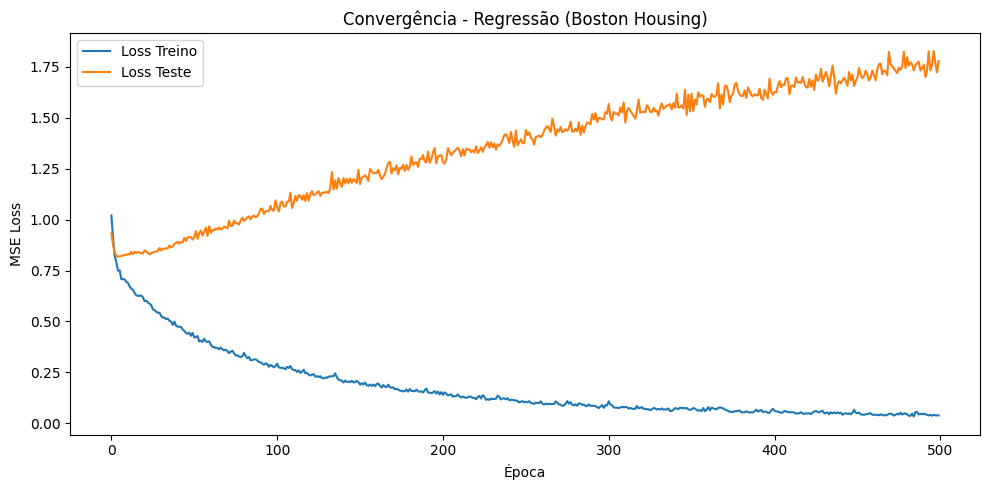

In [108]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Loss Treino')
ax.plot(test_losses, label='Loss Teste')
ax.set_xlabel('Época')
ax.set_ylabel('MSE Loss')
ax.set_title('Convergência - Regressão (Boston Housing)')
ax.legend()
plt.tight_layout()
plt.show()

TODO: Como corrigir?

### 1.7 Persistência — Salvar o Modelo

In [71]:
# Salvar os pesos do modelo
torch.save(model_reg.state_dict(), 'pesos/mlp_regressao_boston.pth')
print('Modelo salvo em pesos/mlp_regressao_boston.pth')

Modelo salvo em pesos/mlp_regressao_boston.pth


### 1.8 Persistência — Carregar e Usar o Modelo

In [72]:
# Carregar o modelo salvo
modelo_carregado = MLPRegressao().to(device)
modelo_carregado.load_state_dict(torch.load('pesos/mlp_regressao_boston.pth'))
modelo_carregado.eval()  # Colocar em modo de avaliação

# Carregar os scalers salvos
x_scaler = joblib.load('scalers/boston_x_scaler.pkl')
y_scaler = joblib.load('scalers/boston_y_scaler.pkl')

print('Modelo e scalers carregados com sucesso!')

Modelo e scalers carregados com sucesso!


In [73]:
# Avaliar no conjunto de teste
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        preds = modelo_carregado(inputs).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

# Reverter o escalonamento para os valores reais
preds_reais = y_scaler.inverse_transform(all_preds)
labels_reais = y_scaler.inverse_transform(all_labels)

mse = mean_squared_error(labels_reais, preds_reais)
r2 = r2_score(labels_reais, preds_reais)
print(f'MSE (valores reais): {mse:.2f}')
print(f'R²: {r2:.4f}')

# Mostrar algumas previsões
print('\n--- Exemplos de Previsões ---')
for i in range(5):
    print(f'Real: {labels_reais[i][0]:.1f} | Previsto: {preds_reais[i][0]:.1f}')

MSE (valores reais): 20277.26
R²: -0.9960

--- Exemplos de Previsões ---
Real: 192.0 | Previsto: 149.0
Real: 165.0 | Previsto: 265.7
Real: 275.0 | Previsto: 118.8
Real: 338.0 | Previsto: 179.4
Real: 423.0 | Previsto: -150.8


---
# Parte 2 — Classificação Binária (Diabetes)

**Objetivo:** Prever se um paciente tem diabetes (0 ou 1) com base em 8 características.

- Loss: `BCELoss` (Binary Cross-Entropy)
- Saída: 1 neurônio + **Sigmoid** (probabilidade entre 0 e 1)

### 2.1 Explorar os Dados

In [9]:
# Este dataset já vem escalonado (pré-processado)
df_diabetes = pd.read_csv('data/diabetes.csv', header=None)
print(f'Shape: {df_diabetes.shape}')
print(f'\nDistribuição das classes:')
print(df_diabetes.iloc[:, -1].value_counts())
df_diabetes.head()

Shape: (759, 9)

Distribuição das classes:
8
1    496
0    263
Name: count, dtype: int64


,0,1,2,3,4,5,6,7,8
0,-0.294118,0.487437,0.180328,-0.292929,0.000000,0.001490,-0.531170,-0.033333,0
1,-0.882353,-0.145729,0.081967,-0.414141,0.000000,-0.207153,-0.766866,-0.666667,1
2,-0.058824,0.839196,0.049180,0.000000,0.000000,-0.305514,-0.492741,-0.633333,0
3,-0.882353,-0.105528,0.081967,-0.535354,-0.777778,-0.162444,-0.923997,0.000000,1
4,0.000000,0.376884,-0.344262,-0.292929,-0.602837,0.284650,0.887276,-0.600000,0


### 2.2 Criar o Dataset

In [25]:
class DiabetesDataset(Dataset):
    def __init__(self):
        # Este dataset já está escalonado!
        xy = np.loadtxt('data/diabetes.csv',
                        delimiter=',', dtype=np.float32)
        self.len = xy.shape[0]
        self.x_data = from_numpy(xy[:, 0:-1])  # 8 features
        self.y_data = from_numpy(xy[:, [-1]])   # 0 ou 1

    def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]

    def __len__(self):
        return self.len

### 2.3 Dividir em Treino e Teste + DataLoader

In [26]:
dataset_diabetes = DiabetesDataset()

train_size = int(0.8 * len(dataset_diabetes))
test_size = len(dataset_diabetes) - train_size
train_dataset_d, test_dataset_d = random_split(dataset_diabetes, [train_size, test_size])

print(f'Treino: {len(train_dataset_d)} | Teste: {len(test_dataset_d)}')

train_loader_d = DataLoader(dataset=train_dataset_d, batch_size=32, shuffle=True)
test_loader_d  = DataLoader(dataset=test_dataset_d,  batch_size=32, shuffle=False)

Treino: 607 | Teste: 152


### 2.4 Definir a Rede MLP para Classificação Binária

Arquitetura:
```
Input (8) → Linear(32) → ReLU → Linear(16) → ReLU → Linear(1) → Sigmoid
```

**Nota:** A `Sigmoid` na saída transforma o valor em probabilidade [0, 1].

In [27]:
class MLPBinario(nn.Module):
    def __init__(self, input_size, hidden_sizes):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Linear(hidden_sizes[1], 1),
            nn.Sigmoid()  # Saída entre 0 e 1
        )

    def forward(self, x):
        return self.layers(x)

### 2.5 Treinamento

In [28]:
#model_bin = MLPBinario(input_size=8, hidden_sizes=(32, 16)).to(device)
model_bin = MLPBinario(input_size=8, hidden_sizes=(8, 4)).to(device)
criterion_bin = nn.BCELoss(reduction='mean')
optimizer_bin = optim.Adam(model_bin.parameters(), lr=0.01)

n_epochs = 1000
train_losses_b = []
test_losses_b = []
train_accs = []
test_accs = []

for epoch in range(n_epochs):
    # --- TREINO ---
    model_bin.train()
    epoch_loss = 0
    correct = 0
    total = 0
    for inputs, labels in train_loader_d:
        inputs, labels = inputs.to(device), labels.to(device)

        y_pred = model_bin(inputs)
        loss = criterion_bin(y_pred, labels)

        optimizer_bin.zero_grad()
        loss.backward()
        optimizer_bin.step()

        epoch_loss += loss.item()
        predicted = (y_pred >= 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_losses_b.append(epoch_loss / len(train_loader_d))
    train_accs.append(correct / total)

    # --- TESTE ---
    model_bin.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader_d:
            inputs, labels = inputs.to(device), labels.to(device)
            y_pred = model_bin(inputs)
            test_loss += criterion_bin(y_pred, labels).item()
            predicted = (y_pred >= 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_losses_b.append(test_loss / len(test_loader_d))
    test_accs.append(correct / total)

    if (epoch + 1) % 250 == 0:
        print(f'Época {epoch+1}/{n_epochs} | '
              f'Loss Treino: {train_losses_b[-1]:.4f} | '
              f'Loss Teste: {test_losses_b[-1]:.4f} | '
              f'Acc Treino: {train_accs[-1]:.2%} | '
              f'Acc Teste: {test_accs[-1]:.2%}')

Época 250/1000 | Loss Treino: 0.3847 | Loss Teste: 1.1634 | Acc Treino: 79.74% | Acc Teste: 76.97%
Época 500/1000 | Loss Treino: 0.3658 | Loss Teste: 1.8475 | Acc Treino: 80.23% | Acc Teste: 76.32%
Época 750/1000 | Loss Treino: 0.3864 | Loss Teste: 1.7940 | Acc Treino: 80.40% | Acc Teste: 76.32%
Época 1000/1000 | Loss Treino: 0.3616 | Loss Teste: 2.3446 | Acc Treino: 81.05% | Acc Teste: 76.97%


### 2.6 Curvas de Convergência

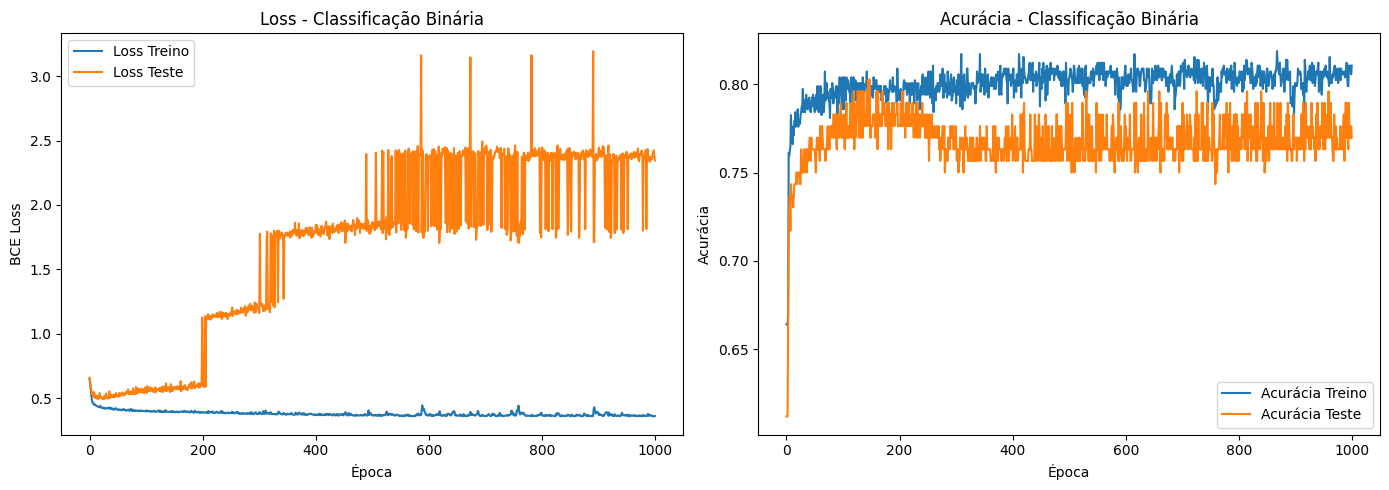

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses_b, label='Loss Treino')
ax1.plot(test_losses_b, label='Loss Teste')
ax1.set_xlabel('Época')
ax1.set_ylabel('BCE Loss')
ax1.set_title('Loss - Classificação Binária')
ax1.legend()

ax2.plot(train_accs, label='Acurácia Treino')
ax2.plot(test_accs, label='Acurácia Teste')
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia')
ax2.set_title('Acurácia - Classificação Binária')
ax2.legend()

plt.tight_layout()
plt.show()

### 2.7 Persistência — Salvar o Modelo

In [30]:
torch.save(model_bin.state_dict(), 'pesos/mlp_binario_diabetes.pth')
print('Modelo salvo em pesos/mlp_binario_diabetes.pth')

Modelo salvo em pesos/mlp_binario_diabetes.pth


### 2.8 Persistência — Carregar e Avaliar

In [31]:
# Carregar o modelo
#modelo_bin_carregado = MLPBinario(input_size=8, hidden_sizes=(32, 16)).to(device)
modelo_bin_carregado = MLPBinario(input_size=8, hidden_sizes=(8, 4)).to(device)

modelo_bin_carregado.load_state_dict(torch.load('pesos/mlp_binario_diabetes.pth'))
modelo_bin_carregado.eval()

# Avaliar no teste
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader_d:
        inputs = inputs.to(device)
        preds = modelo_bin_carregado(inputs).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

y_pred_classes = (all_preds >= 0.5).astype(float)
acc = accuracy_score(all_labels, y_pred_classes)
print(f'Acurácia no teste: {acc:.2%}')

# Exemplos individuais
print('\n--- Exemplos ---')
for i in range(5):
    print(f'Prob: {all_preds[i][0]:.4f} | Pred: {int(y_pred_classes[i][0])} | Real: {int(all_labels[i][0])}')

Acurácia no teste: 76.97%

--- Exemplos ---
Prob: 1.0000 | Pred: 1 | Real: 1
Prob: 0.6619 | Pred: 1 | Real: 0
Prob: 1.0000 | Pred: 1 | Real: 1
Prob: 1.0000 | Pred: 1 | Real: 1
Prob: 0.0592 | Pred: 0 | Real: 0


---
# Parte 3 — Classificação Multiclasse (Wine)

**Objetivo:** Classificar vinhos em 3 categorias com base em 13 características químicas.

- Loss: `CrossEntropyLoss` (já inclui Softmax internamente)
- Saída: 3 neurônios (logits, **sem Softmax** na rede)
- Labels: inteiros começando em 0 (não one-hot)

### 3.1 Explorar os Dados

In [48]:
df_wine = pd.read_csv('data/wine.csv')
print(f'Shape: {df_wine.shape}')
print(f'\nDistribuição das classes:')
print(df_wine['Wine'].value_counts().sort_index())
df_wine.head()

Shape: (178, 14)

Distribuição das classes:
Wine
1    59
2    71
3    48
Name: count, dtype: int64


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


### 3.2 Criar o Dataset com Escalonamento

In [49]:
class WineDataset(Dataset):
    def __init__(self, scale_data=True):
        xy = np.loadtxt('data/wine.csv',
                        delimiter=',', dtype=np.float32, skiprows=1)

        self.len = xy.shape[0]
        x_data = xy[:, 1:]        # 13 features
        self.y_data = xy[:, 0] - 1  # Classes: 0, 1, 2 (começar em zero!)

        # Escalonamento das features
        if scale_data:
            self.x_scaler = StandardScaler()
            x_data = self.x_scaler.fit_transform(x_data)
            joblib.dump(self.x_scaler, 'scalers/wine_x_scaler.pkl')

        self.x_data = from_numpy(x_data)
        self.y_data = torch.tensor(self.y_data, dtype=torch.long)  # CrossEntropy espera Long!

    def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]

    def __len__(self):
        return self.len

### 3.3 Dividir em Treino e Teste + DataLoader

In [50]:
dataset_wine = WineDataset()

train_size = int(0.8 * len(dataset_wine))
test_size = len(dataset_wine) - train_size
train_dataset_w, test_dataset_w = random_split(dataset_wine, [train_size, test_size])

print(f'Treino: {len(train_dataset_w)} | Teste: {len(test_dataset_w)}')

train_loader_w = DataLoader(dataset=train_dataset_w, batch_size=32, shuffle=True)
test_loader_w  = DataLoader(dataset=test_dataset_w,  batch_size=32, shuffle=False)

Treino: 142 | Teste: 36


### 3.4 Definir a Rede MLP para Classificação Multiclasse

Arquitetura:
```
Input (13) → Linear(64) → ReLU → Linear(32) → ReLU → Linear(3)
```

**Nota:** `CrossEntropyLoss` já aplica o Softmax internamente! Não coloque Softmax na rede.

In [51]:
class MLPMulticlasse(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, num_classes)
            # SEM Softmax aqui! CrossEntropyLoss já faz isso.
        )

    def forward(self, x):
        return self.layers(x)

### 3.5 Treinamento com Salvamento dos Melhores Pesos

In [54]:
model_multi = MLPMulticlasse(input_size=13, hidden_size=64, num_classes=3).to(device)
criterion_multi = nn.CrossEntropyLoss()  # Já aplica Softmax
optimizer_multi = optim.Adam(model_multi.parameters(), lr=1e-2)

n_epochs = 100
train_losses_w = []
test_losses_w = []
train_accs_w = []
test_accs_w = []
best_test_acc = 0

for epoch in range(n_epochs):
    # --- TREINO ---
    model_multi.train()
    epoch_loss = 0
    correct = 0
    total = 0
    for inputs, labels in train_loader_w:
        inputs, labels = inputs.to(device), labels.to(device)

        y_pred = model_multi(inputs)
        loss = criterion_multi(y_pred, labels)

        optimizer_multi.zero_grad()
        loss.backward()
        optimizer_multi.step()

        epoch_loss += loss.item()
        _, predicted = torch.max(y_pred, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_losses_w.append(epoch_loss / len(train_loader_w))
    train_accs_w.append(correct / total)

    # --- TESTE ---
    model_multi.eval()
    test_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader_w:
            inputs, labels = inputs.to(device), labels.to(device)
            y_pred = model_multi(inputs)
            test_loss += criterion_multi(y_pred, labels).item()
            _, predicted = torch.max(y_pred, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_acc = correct / total
    test_losses_w.append(test_loss / len(test_loader_w))
    test_accs_w.append(test_acc)

    # Salvar os melhores pesos
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        torch.save(model_multi.state_dict(), 'pesos/mlp_wine_melhor.pth')

    if (epoch + 1) % 10 == 0:
        print(f'Época {epoch+1}/{n_epochs} | '
              f'Loss: {train_losses_w[-1]:.4f} | '
              f'Acc Treino: {train_accs_w[-1]:.2%} | '
              f'Acc Teste: {test_accs_w[-1]:.2%}')

print(f'\nMelhor acurácia no teste: {best_test_acc:.2%}')

Época 10/100 | Loss: 0.0007 | Acc Treino: 100.00% | Acc Teste: 100.00%
Época 20/100 | Loss: 0.0002 | Acc Treino: 100.00% | Acc Teste: 100.00%
Época 30/100 | Loss: 0.0001 | Acc Treino: 100.00% | Acc Teste: 100.00%
Época 40/100 | Loss: 0.0001 | Acc Treino: 100.00% | Acc Teste: 100.00%
Época 50/100 | Loss: 0.0001 | Acc Treino: 100.00% | Acc Teste: 100.00%
Época 60/100 | Loss: 0.0000 | Acc Treino: 100.00% | Acc Teste: 100.00%
Época 70/100 | Loss: 0.0001 | Acc Treino: 100.00% | Acc Teste: 100.00%
Época 80/100 | Loss: 0.0000 | Acc Treino: 100.00% | Acc Teste: 100.00%
Época 90/100 | Loss: 0.0000 | Acc Treino: 100.00% | Acc Teste: 100.00%
Época 100/100 | Loss: 0.0000 | Acc Treino: 100.00% | Acc Teste: 100.00%

Melhor acurácia no teste: 100.00%


### 3.6 Curvas de Convergência

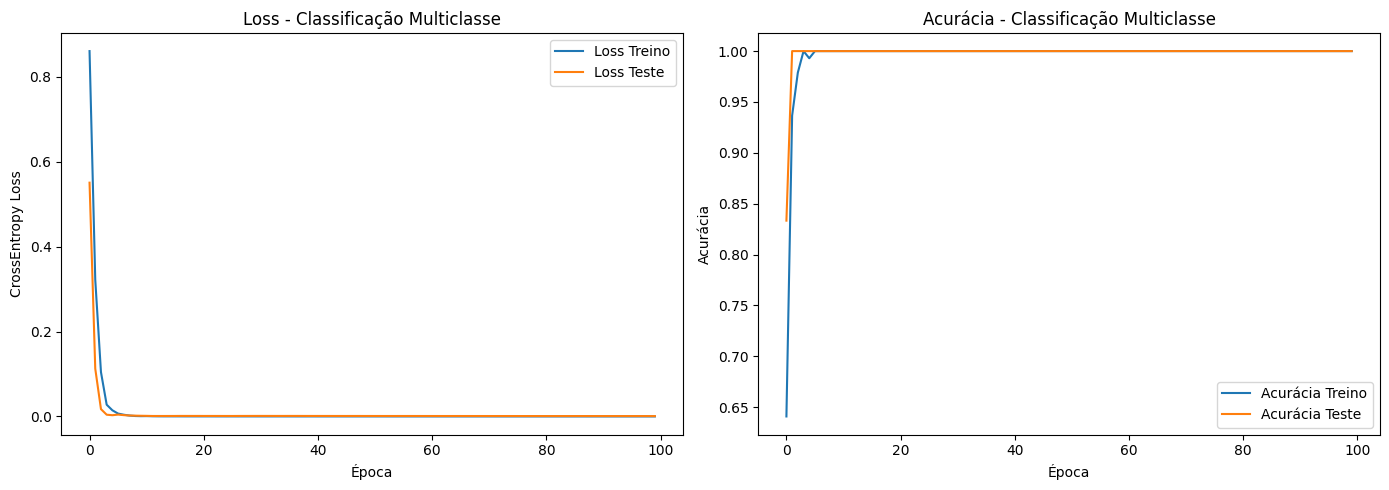

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses_w, label='Loss Treino')
ax1.plot(test_losses_w, label='Loss Teste')
ax1.set_xlabel('Época')
ax1.set_ylabel('CrossEntropy Loss')
ax1.set_title('Loss - Classificação Multiclasse')
ax1.legend()

ax2.plot(train_accs_w, label='Acurácia Treino')
ax2.plot(test_accs_w, label='Acurácia Teste')
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia')
ax2.set_title('Acurácia - Classificação Multiclasse')
ax2.legend()

plt.tight_layout()
plt.show()

### 3.7 Persistência — Carregar e Usar o Melhor Modelo

In [56]:
# Carregar o melhor modelo
modelo_wine = MLPMulticlasse(input_size=13, hidden_size=64, num_classes=3).to(device)
modelo_wine.load_state_dict(torch.load('pesos/mlp_wine_melhor.pth'))
modelo_wine.eval()

# Carregar o scaler
x_scaler_wine = joblib.load('scalers/wine_x_scaler.pkl')

# Previsão de um exemplo individual
softmax = nn.Softmax(dim=0)

with torch.no_grad():
    for i in range(5):
        x_val, y_val = dataset_wine[i]
        x_val = x_val.to(device)
        logits = modelo_wine(x_val)
        probs = softmax(logits)
        classe_pred = torch.argmax(probs).item()
        print(f'Amostra {i}: Probs={probs.cpu().numpy().round(3)} | '
              f'Previsto: {classe_pred} | Real: {y_val.item()}')

Amostra 0: Probs=[0.997 0.003 0.   ] | Previsto: 0 | Real: 0
Amostra 1: Probs=[0.91  0.087 0.003] | Previsto: 0 | Real: 0
Amostra 2: Probs=[0.986 0.013 0.   ] | Previsto: 0 | Real: 0
Amostra 3: Probs=[1. 0. 0.] | Previsto: 0 | Real: 0
Amostra 4: Probs=[0.902 0.086 0.011] | Previsto: 0 | Real: 0


---
# Resumo Comparativo

| Aspecto | Regressão | Classificação Binária | Classificação Multiclasse |
|---|---|---|---|
| **Loss** | `MSELoss` | `BCELoss` | `CrossEntropyLoss` |
| **Saída** | 1 neurônio (linear) | 1 neurônio + Sigmoid | N neurônios (logits) |
| **Ativação final** | Nenhuma | Sigmoid | Nenhuma (Softmax no Loss) |
| **Tipo do label** | Float | Float (0.0 ou 1.0) | Long (0, 1, 2, ...) |
| **Métrica** | MSE, R² | Acurácia, F1 | Acurácia |

### Fluxo padrão com persistência:
1. Criar `Dataset` customizado (com `StandardScaler`)
2. Salvar o scaler com `joblib.dump()`
3. Dividir com `random_split()` e criar `DataLoader`
4. Treinar e salvar pesos com `torch.save(model.state_dict(), ...)`
5. Carregar com `model.load_state_dict(torch.load(...))` e `joblib.load()`